# Training Baseline:
- Read the two artifacts from `01_data_eda.ipynb` notebook as the ground-truth input of the whole project:
-  `/experiments/pools/source_pool_rel.csv`
-  `/experiments/pools/preprocessing_config.json`
- Build the Dataset class (`CXRThreeClassDataset`).
- Define the shared preprocessing transforms (ImageNet normalisation, etc).
- Createss *train/val DataLoaders* for a single *80/20* split.
This keeps **everything in memory**. No saving of models, metrics, or new CSVs.
This notebook role is purely to verify that those artifacts load correctly and yield balanced splits.

 ## 1. Overview: Preprocessing rationale.

This notebook loads the preprocessing configuration saved during EDA.
All experiments use:
- 256×256 RGB inputs (or 320×320 for sensitivity analysis).
- ImageNet normalisation (mean/std).
- Unified three-class mapping: Pneumonia (CheXpert), TB and Normal (TBX11K).

Below, the configuration is automatically loaded from /experiments/pools/`preprocessing_config.json`.

In [1]:
# Define a reproducible preprocessing pipeline for training and validation/testing.

# Toggle here for running the sensitivity analysis.
IMG_SIZE = 256 # Set to 320 for the sensitivity analysis.

print(f'Preprocessing ready at {IMG_SIZE}x{IMG_SIZE} RGB.')
print(f'- CheXpert: grayscale -> RGB + normalisation.')
print(f'- TBX11K  : RGB + normalisation.')

# Clarify the modelling classes and their data sources (for logging/record-keeping).
print("\nClasses that will be used for training: \n- 'Pneumonia' (CheXpert frontal-only)\n- 'Normal' (TBX11K) \n- 'TB' (TBX11K)")

Preprocessing ready at 256x256 RGB.
- CheXpert: grayscale -> RGB + normalisation.
- TBX11K  : RGB + normalisation.

Classes that will be used for training: 
- 'Pneumonia' (CheXpert frontal-only)
- 'Normal' (TBX11K) 
- 'TB' (TBX11K)


## 2a. Load Artefacts and **Normalisation Toggle**.
Load persisted EDA artefacts to rebuild the unified dataset and ensure reproducibility.
#### Rationale:
- Reuse saved files (source_pool_rel.csv, preprocessing_config.json) instead of regenerating them.
- Add a toggle to switch between:
    - ImageNet stats: for pretrained models (MobileNetV2, EfficientNet-B0, ResNet-50).
    - CXR stats: for custom CNNs using dataset-specific mean/std.
- Maintain consistent preprocessing across all experiments.

In [2]:
# Build a unified three-class Dataset using RELATIVE paths (mirror 01_data_eda.ipynb behavior).
# Instead of reconstructing DataFrames again, load the already persisted artefacts produced by EDA.
# This ensures reproducibility and avoids duplication of logic between notebooks.

from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
import json

# --- Load persisted artefacts from EDA (source_pool_rel.csv + preprocessing_config.json) ---.
PROJECT_ROOT = Path("..").resolve()
CHEXPERT_PATH = PROJECT_ROOT / "data" / "chexpert"
TBX11K_PATH = PROJECT_ROOT / "data" / "tbx11k"

# Load the unified pool with relative paths, class names, and source tags.
source_pool_rel = pd.read_csv(PROJECT_ROOT / "experiments" / "pools" / "source_pool_rel.csv")

# Load preprocessing config (IMG_SIZE, ImageNet stats, label map).
with open(PROJECT_ROOT / "experiments" / "pools" / "preprocessing_config.json", "r") as f:
    cfg = json.load(f)

CLASS_TO_INDEX = {k: int(v) for k, v in cfg["class_to_index"].items()}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}

print("Loaded persisted EDA artefacts successfully:")
print(f'- Classes: {CLASS_TO_INDEX}')
print(f'- IMG_SIZE: {cfg["img_size"]}')
print(f'- Transform mode: {cfg["transform_mode"]}')
print(f'- Total samples: {len(source_pool_rel):,}')

# --- Choose normalisation source ---
# Allows flexible selection of mean/std parameters for preprocessing.
# Set USE_IMAGENET_STATS = True to reproduce pretrained baselines (MobileNetV2, EfficientNet-B0, ResNet-50).
# Set to False to use dataset-specific statistics computed in 01_data_eda.ipynb (for custom CNNs).

USE_IMAGENET_STATS = True  # Change manually when needed.

if USE_IMAGENET_STATS:
    MEAN = cfg["imagenet_mean"]
    STD  = cfg["imagenet_std"]
    source = "ImageNet"
else:
    MEAN = cfg["cxr_mean"]
    STD  = cfg["cxr_std"]
    source = "CXR (dataset-specific)"

print(f"\nUsing {source} normalisation:")
print(f"  mean = {MEAN}")
print(f"  std  = {STD}")

Loaded persisted EDA artefacts successfully:
- Classes: {'Pneumonia': 0, 'TB': 1, 'Normal': 2}
- IMG_SIZE: 256
- Transform mode: letterbox
- Total samples: 13,651

Using ImageNet normalisation:
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]


## 2b. Normalisation Toggle:
Compute once and reuse the same preprocessing configuration for all experiments.
#### Rationale:
- Allow the same pipeline to operate in two modes:
    - ImageNet statistics (USE_IMAGENET_STATS = True): for transfer learning with pretrained backbones (MobileNetV2, EfficientNet-B0, ResNet-50).
    - CXR dataset statistics (USE_IMAGENET_STATS = False): for training custom CNNs from scratch using the global mean and standard deviation computed in 01_data_eda.ipynb.

- Ensure reproducibility and fair comparison between pretrained and dataset-specific normalisation strategies.
- Keep preprocessing consistent across notebooks and experiments.

In [3]:
# Unified Dataset class.
class CXRThreeClassDataset(Dataset):
    """
    Provide a unified three-class CXR dataset with the fixed label order:
      0 : 'Pneumonia' (CheXpert frontal-only)
      1 : 'TB'        (TBX11K)
      2 : 'Normal'    (TBX11K)

    Absolute paths are built at access time depending on the "Source" column.
    This class implements the standard PyTorch Dataset API (len, getitem).
    """

    def __init__(self, items: pd.DataFrame, transforms, chexpert_root: Path, tbx_root: Path):
        # Store the DataFrame of items (relative paths + labels + sources).
        # Resetting the index ensures sequential indices from 0...n-1 for safe access.
        self.items = items.reset_index(drop=True)

        # Save preprocessing transforms (data augmentation / normalisation).
        self.transforms = transforms

        # Save root paths to both datasets: need to build absolute paths later.
        self.chexpert_root = chexpert_root
        self.tbx_root = tbx_root

    def __len__(self) -> int:
        # Required by PyTorch: return the total number of samples in the dataset.
        return len(self.items)

    def __getitem__(self, idx: int):
        # Fetch the metadata for a single sample (row from the DataFrame).
        row = self.items.iloc[idx]

        # Build the absolute file path:
        # - If from CheXpert, join with CheXpert root.
        # - If from TBX11K, join with tbx_root + "imgs" folder.
        abs_path = (
            self.chexpert_root / row["rel_path"]
            if row["Source"] == "chexpert"
            else self.tbx_root / "imgs" / row["rel_path"]
        )

        # Load the image and convert to RGB explicitly.
        # This ensures grayscale CheXpert images become 3-channel, consistent with TBX11K and ImageNet.
        img = Image.open(abs_path).convert("RGB")

        # Apply preprocessing transforms if provided (resize, normalise, augment).
        if self.transforms is not None:
            img = self.transforms(img)

        # Convert the class string (e.g., "TB") into its numeric index (0/1/2).
        label = CLASS_TO_INDEX[row["Class"]]

        # Return a tuple (image tensor, label tensor) ready for PyTorch DataLoader.
        return img, torch.tensor(label, dtype=torch.long)

# --- Instantiate the unified PyTorch Dataset over the full pool ---
train_dataset = CXRThreeClassDataset(
    items=source_pool_rel, # Full unified table created during 01_data_eda.ipynb.
    transforms=None,  # Temporarily none; it will attach shared transform later.
    chexpert_root=CHEXPERT_PATH, # Root path for CheXpert dataset.
    tbx_root=TBX11K_PATH # Root path for TBX11K dataset.
)

# Report readiness: dataset length and label order mapping.
print(f'\nCXRThreeClassDataset ready (relative-path mode): {len(train_dataset)} samples, label order={INDEX_TO_CLASS}')


CXRThreeClassDataset ready (relative-path mode): 13651 samples, label order={0: 'Pneumonia', 1: 'TB', 2: 'Normal'}


## 3. Share Preprocessing (Unified Train/Eval Transforms).
Define a single train/eval pipeline at 256×256 RGB with ImageNet normalisation. Preserve aspect ratio and use a centre crop (deterministic) to avoid chopping diagnostically important borders.
#### Rationale:
- Enforce identical preprocessing across sources to avoid domain-specific bias.
- Align inputs with ImageNet-pretrained backbones (RGB + mean/std) for stable transfer.
- Preserve aspect ratio on resize; prefer centre crop over random crop to keep anatomy intact (apices, costophrenic angles, etc.).
- Apply minimal, label-safe augmentation (random horizontal flip) suitable for frontal CXRs.

In [4]:
# Shared transforms for BOTH datasets (CheXpert + TBX11K), using parameters loaded from the persisted config.
# This ensures identical preprocessing across all experiments and notebooks.
# The transforms enforce RGB input, normalisation (ImageNet or CXR depending on toggle), and safe horizontal flipping for frontal CXRs.

from torchvision.transforms import InterpolationMode
from torchvision import transforms as T

# Extract image size directly from the loaded configuration (cfg).
IMG_SIZE = int(cfg["img_size"])

train_transforms_shared = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),  # Scale shortest side to IMG_SIZE (preserve aspect).
                                                                                   # Smooth resize.
    T.CenterCrop(IMG_SIZE),  # Deterministic crop; keeps central anatomy.
    T.RandomHorizontalFlip(p=0.5),  # Safe augmentation for frontal CXRs.
    T.ToTensor(),  # HWC (Height, Width, Channel -> CHW (Channel, Height, Width)), convert to tensor [0..1].
    T.Normalize(MEAN, STD)  # Use mean/std based on toggle defined above (ImageNet or CXR).
])

eval_transforms_shared = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True),  # Preserve aspect ratio.
    T.CenterCrop(IMG_SIZE),  # Deterministic crop for evaluation.
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# Attach to the current dataset instance (created above).
train_dataset.transforms = train_transforms_shared  # Use shared training pipeline now.

print(f'Transforms attached successfully: {IMG_SIZE}x{IMG_SIZE} with "{"ImageNet" if USE_IMAGENET_STATS else "CXR"}" normalisation.')

Transforms attached successfully: 256x256 with "ImageNet" normalisation.


## 4. Sanity Check: Verify Shared Transforms Are Applied.
Fetch one item per source via `train_dataset` and inspect tensor properties.
#### Rationale:
- Confirm output shape is (3, 256, 256) and dtype is `float32`.
- Confirm values are normalised (roughly centred near 0).
- Ensure CheXpert (grayscale) arrives as RGB after conversion.
- Catch any path/IO issue early.

CheXpert sample: shape=(3, 256, 256), dtype=torch.float32, label=0
  mean=0.530, std=1.187, min=-2.118, max=2.640
TBX11K sample: shape=(3, 256, 256), dtype=torch.float32, label=1
  mean=-0.040, std=1.269, min=-2.118, max=2.326


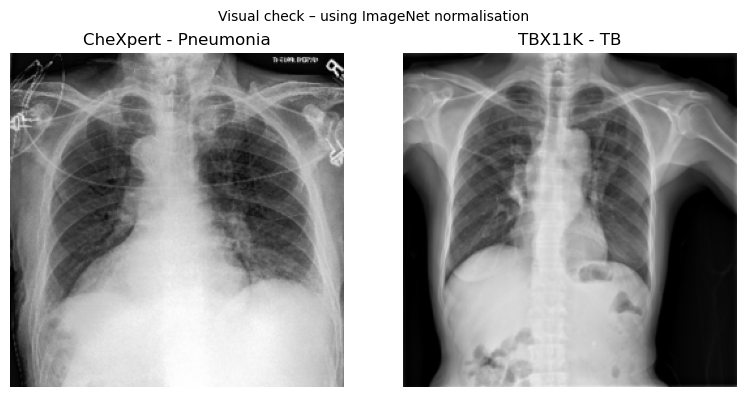

In [5]:
# Sanity-check a CheXpert and TBX11K sample after transforms (no images saved).
import torch
import matplotlib.pyplot as plt

# Find one index per source from the dataset's items table.
chex_idx = train_dataset.items.index[train_dataset.items["Source"] == "chexpert"][0]
tbx_idx  = train_dataset.items.index[train_dataset.items["Source"] == "tbx11k"][0]

# Pull samples (applied current train_dataset.transforms).
x_chex, y_chex = train_dataset[chex_idx]
x_tbx, y_tbx   = train_dataset[tbx_idx]

def summ(name, x, y):
    print(f'{name}: shape={tuple(x.shape)}, dtype={x.dtype}, label={int(y)}')
    # Quick stats on a small subset of elements to avoid huge prints.
    t = x.flatten()
    print(f'  mean={t.mean().item():.3f}, std={t.std().item():.3f}, min={t.min().item():.3f}, max={t.max().item():.3f}')

summ("CheXpert sample", x_chex, y_chex)
summ("TBX11K sample", x_tbx, y_tbx)

# --- Show the images below (inverse-normalise) ---
# Use the same mean/std selected earlier via the USE_IMAGENET_STATS toggle.
image_mean = torch.tensor(MEAN).view(3, 1, 1)
image_std  = torch.tensor(STD).view(3, 1, 1)

def denorm_np(x: torch.Tensor):
    # Invert normalisation for visualisation
    x = (x * image_std + image_mean).clamp(0, 1)
    return x.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(denorm_np(x_chex)); ax[0].axis("off"); ax[0].set_title(f'CheXpert - {INDEX_TO_CLASS[int(y_chex)]}')
ax[1].imshow(denorm_np(x_tbx));  ax[1].axis("off"); ax[1].set_title(f'TBX11K - {INDEX_TO_CLASS[int(y_tbx)]}')
plt.suptitle(f"Visual check – using {'ImageNet' if USE_IMAGENET_STATS else 'CXR'} normalisation", fontsize=10)
plt.tight_layout(); plt.show()

## 5. Build train/val DataLoaders from the pooled artefacts
Load the unified pool + preprocessing config saved in EDA, rebuild transforms, make a stratified 80/20 split, and return PyTorch DataLoaders.
It is important not to use the same data for both training and testing, because it is needed to know how the method will work on data it was not trained on.
#### Rationale:
- Reuse exactly the same label map and normalisation across notebooks (reproducibility).
- Keep class proportions identical in train/val via stratified split (fair evaluation).
- Attach train vs eval transforms at the split level (correct augmentation semantics).
- Produce DataLoaders tuned for GPU throughput (pinning, workers), ready for training.

In [6]:
# Minimal loader setup: reuse artefacts -> transforms (centre-crop) -> stratified 80/20 -> DataLoaders.

from pathlib import Path
import torch, pandas as pd
from torch.utils import data
from torch.utils.data import DataLoader, Subset
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
from sklearn.model_selection import StratifiedShuffleSplit

# 1. Reuse pooled table and preprocessing config loaded earlier from EDA artefacts.
#   This avoids redundant I/O and guarantees consistency.
pooled_table = source_pool_rel.copy() # already loaded earlier.
preprocessing_config = cfg # reuse the loaded config.

# 2. Restore label map and image stats from config (single source of truth -> no silent drift).
CLASS_TO_INDEX = {k: int(v) for k, v in preprocessing_config["class_to_index"].items()}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}
IMG_SIZE       = int(preprocessing_config["img_size"])

# 3. Require the Dataset class defined earlier; it composes absolute paths and converts to RGB.
if "CXRThreeClassDataset" not in globals():
    raise RuntimeError("Define CXRThreeClassDataset before running this cell.")

# 4. Wrap the entire pool in one dataset; split below controls which indices belong to train/val.
full_dataset = CXRThreeClassDataset(
    pooled_table[["rel_path", "Class", "Source"]],
    transforms=None,  # set per-split to ensure correct augmentations.
    chexpert_root=CHEXPERT_PATH,
    tbx_root=TBX11K_PATH
)

# 5. Make a stratified 80/20 split so each class keeps its proportion in both sets.
y_labels = pooled_table["Class"].map(CLASS_TO_INDEX).values  # numeric labels for splitting.
strat_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, val_indices = next(strat_splitter.split(y_labels, y_labels))
train_subset, val_subset = Subset(full_dataset, train_indices), Subset(full_dataset, val_indices)

# 6. Attach the correct transforms per split (Subset forwards to the underlying dataset object).
full_dataset.transforms         = train_transforms_shared        # default (optional)
train_subset.dataset.transforms = train_transforms_shared
val_subset.dataset.transforms   = eval_transforms_shared

# 7. Build DataLoaders.
#  In torch.utils.data.DataLoader, num_workers enables parallel data loading using subprocesses, 
#  while pin_memory=True enables faster data transfers to CUDA-enabled GPUs by allocating data 
#  tensors in pinned (non-swappable) memory. Using both together is a common strategy to improve 
#  training speed by overlapping data preparation with GPU computation.
# - num_workers: increase if disk can keep up (RTX 5090 used can handle >4).
# - pin_memory: enable when using CUDA to speed host->device transfer (Cuda 12.8 is used).
train_loader = DataLoader(
    train_subset, 
    batch_size=128, # Try 128; increase to 256+ if VRAM allows. 
    shuffle=True, 
    num_workers=10, # ~40% of the Stellaris 24 cores.
    pin_memory=torch.cuda.is_available(), # Since the presence of GPU.
    persistent_workers=True, 
    prefetch_factor=2 # Keep GPU fed to avoid it stall  waiting for data and avoid I/O stalls 
                      # (GPU Starvation).
)
val_loader = DataLoader(
    val_subset, 
    batch_size=128, 
    shuffle=False,
    num_workers=5, 
    pin_memory=torch.cuda.is_available(), 
    persistent_workers=True
)

# 8. Print a compact summary to verify split sizes and class balance.
def count_classes(indices):
    return (pd.Series(y_labels[indices])
            .map(INDEX_TO_CLASS)
            .value_counts()
            .reindex(["Pneumonia", "TB", "Normal"], fill_value=0)
            .to_dict())

print("IMG_SIZE:", IMG_SIZE, "| Labels:", CLASS_TO_INDEX)
print(f"Train/Val: {len(train_indices)}/{len(val_indices)}")
print("Train:", count_classes(train_indices))
print("Val:  ", count_classes(val_indices))
print(f"\nDataLoaders ready with '{'ImageNet' if USE_IMAGENET_STATS else 'CXR'}' normalisation.")

IMG_SIZE: 256 | Labels: {'Pneumonia': 0, 'TB': 1, 'Normal': 2}
Train/Val: 10920/2731
Train: {'Pneumonia': 3740, 'TB': 3838, 'Normal': 3342}
Val:   {'Pneumonia': 935, 'TB': 960, 'Normal': 836}

DataLoaders ready with 'ImageNet' normalisation.
